<h1 style="
  font-family: 'Americana XBdCn BT';
  text-shadow: 2px 2px 4px rgba(0,0,0,0.2);
  font-size: 60px;
  font-style: normal;
  background: linear-gradient(to right, #d7df23,#d7df23);
  letter-spacing: 3px;
  color: #000000;
  border-radius: 0px;
  text-align: center;
  line-height: 1;
  padding: 20px 10px;
">
  <span>Ola: The Real Story</span><br>
  <span style="color: #000000;"> Behind Driver Churn</span>
</h1>


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
from pywaffle import Waffle
from matplotlib.patches import Wedge
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings("ignore")

In [2]:
ola = pd.read_csv('ola_driver_scaler.csv')

In [3]:
# --- Step 1: Make a working copy
ola1 = ola.copy()
# --- Step 2: Aggregate per Driver_ID (basic features)
functions = {
    'MMM-YY':'count',                 # Number of reports
    'Age':'max',
    'Gender':'last',
    'City':'last',
    'Education_Level':'last',
    'Dateofjoining':'first',
    'LastWorkingDate':'last',
    'Grade':'last',
    'Total Business Value':'sum',
    'Income':'last',      
    'Joining Designation':'last',
    'Quarterly Rating':'first'}
ola1 = ola1.groupby('Driver_ID').agg(functions).reset_index()
# --- Step 3: Rename monthly count
ola1.rename(columns={'MMM-YY':'Reportings'}, inplace=True)
# --- Step 4: Convert dates
ola1['Dateofjoining'] = pd.to_datetime(ola1['Dateofjoining'])
ola1['LastWorkingDate'] = pd.to_datetime(ola1['LastWorkingDate'])
# --- Step 5: Tenure in months
end_dates = ola1['LastWorkingDate'].fillna(pd.Timestamp.today())
ola1['Tenure_Months'] = (end_dates.dt.year - ola1['Dateofjoining'].dt.year) * 12 + \
                        (end_dates.dt.month - ola1['Dateofjoining'].dt.month)
# --- Step 6: Business increase flag
bv1 = ola.groupby('Driver_ID')['Total Business Value'].first().reset_index()
bv2 = ola.groupby('Driver_ID')['Total Business Value'].last().reset_index()
bv = bv1.merge(bv2, on='Driver_ID', suffixes=('_first','_last'))
bv['Business_Increase'] = np.where(bv['Total Business Value_last'] > bv['Total Business Value_first'], "Yes", "No")
ola1 = ola1.merge(bv[['Driver_ID','Business_Increase']], on='Driver_ID')
# --- Step 7: Age groups
bins = [18,25,35,45,60]
labels = ['18-25','25-35','35-45','45-60']
ola1['Age_Group'] = pd.cut(ola1['Age'], bins=bins, labels=labels, right=False)
# --- Step 8: Income per month
ola1['Income_Per_Month'] = ola1['Income'] / ola1['Reportings']
# --- Step 8.5: Monthly Income Increase Flag
income_first = ola.groupby('Driver_ID')['Income'].first().reset_index()
income_last = ola.groupby('Driver_ID')['Income'].last().reset_index()
income_df = income_first.merge(income_last, on='Driver_ID', suffixes=('_first','_last'))
income_df['Income_Increase'] = np.where(income_df['Income_last'] > income_df['Income_first'], "Yes", "No")
ola1 = ola1.merge(income_df[['Driver_ID','Income_Increase']], on='Driver_ID', how='left')
# --- Step 9: Extract Year and Month of joining
ola1['Year'] = ola1['Dateofjoining'].dt.year
ola1['Month'] = ola1['Dateofjoining'].dt.month
# --- Step 10: Handle negative income & business (capping)
income_upper = ola1['Income'].quantile(0.99)
business_upper = ola1['Total Business Value'].quantile(0.99)
ola1['Income'] = np.clip(ola1['Income'], 0, income_upper)
ola1['Total Business Value'] = np.clip(ola1['Total Business Value'], 0, business_upper)
ola1['Income_Per_Month'] = np.clip(ola1['Income_Per_Month'], 0, income_upper / ola1['Reportings'].max())
# --- Step 11: Create target separately from raw ola
ola_target = ola.groupby('Driver_ID')['LastWorkingDate'].last().reset_index()
ola_target['target'] = ola_target['LastWorkingDate'].apply(lambda x: 'Churners' if pd.notna(x) else 'Non-Churners')
ola_target = ola_target[['Driver_ID','target']]
# --- Step 12: Merge target into final dataframe
ola_final = ola1.merge(ola_target, on='Driver_ID', how='left')
# --- Step 13: Create cancellation flag
ola_final['Cancellation_Flag'] = ola.groupby('Driver_ID')['Total Business Value'] \
                                    .apply(lambda x: 'Yes' if (x < 0).any() else 'No') \
                                    .reset_index(drop=True)
# --- Step 14: Create tenure bins (Tenure_Months)
# Define balanced bins in months for ola_final
bins = [-1, 6, 12, 36, 60, ola_final['Tenure_Months'].max()]
labels = ['0-6 months', '7-12 months', '1-3 years',   '3-5 years', '5+ years' ]   
# Create tenure_bin column
ola_final['tenure_bin'] = pd.cut(ola_final['Tenure_Months'], bins=bins, labels=labels)
# --- Step 15: Quarterly Rating trend flag
# Compare first vs last Quarterly Rating per driver
qr_first = ola.groupby('Driver_ID')['Quarterly Rating'].first()
qr_last = ola.groupby('Driver_ID')['Quarterly Rating'].last()
rating_change = (qr_last > qr_first).replace({True:'Yes', False:'No'})
ola_final['rating_Changes'] = rating_change.values

tenure_bin
0-6 months     878
5+ years       745
7-12 months    333
1-3 years      274
3-5 years      151
Name: count, dtype: int64
rating_Changes
No     2023
Yes     358
Name: count, dtype: int64
target
Churners        1616
Non-Churners     765
Name: count, dtype: int64
Cancellation_Flag
No     2245
Yes     136
Name: count, dtype: int64


In [4]:
# --- Step 1: Calculate 99th percentile caps
income_per_month_cap = ola_final['Income_Per_Month'].quantile(0.99)
total_business_cap = ola_final['Total Business Value'].quantile(0.99)
# --- Step 2: Apply capping permanently
ola_final['Income_Per_Month'] = np.clip(ola_final['Income_Per_Month'], None, income_per_month_cap)
ola_final['Total Business Value'] = np.clip(ola_final['Total Business Value'], None, total_business_cap)
# --- Step 3: Keep the cities numericals
ola_final['City'] = ola_final['City'].astype(str).str.replace(r'\D', '', regex=True)
ola_final['City'] = ola_final['City'].astype(int)
# --- Step 4: Managing Genders
ola = ola_final.copy()
ola['Gender'] = ola['Gender'].map({0.0: 'Male', 1.0: 'Female'})

In [6]:
ola.describe()

,Unnamed: 0,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
count,19104.000000,19104.000000,19043.000000,19052.000000,19104.000000,19104.000000,19104.000000,19104.000000,1.910400e+04,19104.000000
mean,9551.500000,1415.591133,34.668435,0.418749,1.021671,65652.025126,1.690536,2.252670,5.716621e+05,2.008899
std,5514.994107,810.705321,6.257912,0.493367,0.800167,30914.515344,0.836984,1.026512,1.128312e+06,1.009832
min,0.000000,1.000000,21.000000,0.000000,0.000000,10747.000000,1.000000,1.000000,-6.000000e+06,1.000000
25%,4775.750000,710.000000,30.000000,0.000000,0.000000,42383.000000,1.000000,1.000000,0.000000e+00,1.000000
50%,9551.500000,1417.000000,34.000000,0.000000,1.000000,60087.000000,1.000000,2.000000,2.500000e+05,2.000000
75%,14327.250000,2137.000000,39.000000,1.000000,2.000000,83969.000000,2.000000,3.000000,6.997000e+05,3.000000
max,19103.000000,2788.000000,58.000000,1.000000,2.000000,188418.000000,5.000000,5.000000,3.374772e+07,4.000000


In [9]:
fonts = ['DejaVu Serif']
black ="#000000"
green = "#d7df23"
def add_stroke_labels(ax, fontsize, x_vals, y, labels, colors): 
    for x, text, color in zip(x_vals, labels, colors): 
        ax.text(x, y, text,transform=ax.transAxes,fontsize=fontsize,color=color,font=fonts[0],fontweight="bold")

<h1 style="
  font-family: 'Americana XBdCn BT';
  text-shadow: 2px 2px 4px rgba(0,0,0,0.2);
  font-size: 32px;
  font-style: normal;
  background: linear-gradient(to right, #000000,#000000);
  letter-spacing: 0px;
  color: #d7df23;
  border-radius: 0px;
  text-align: center;
  line-height: 1;
  padding: 20px 10px;
">
  <span>Churn O’Clock: Tracking Drivers Through the TIME</span><br>
</h1>


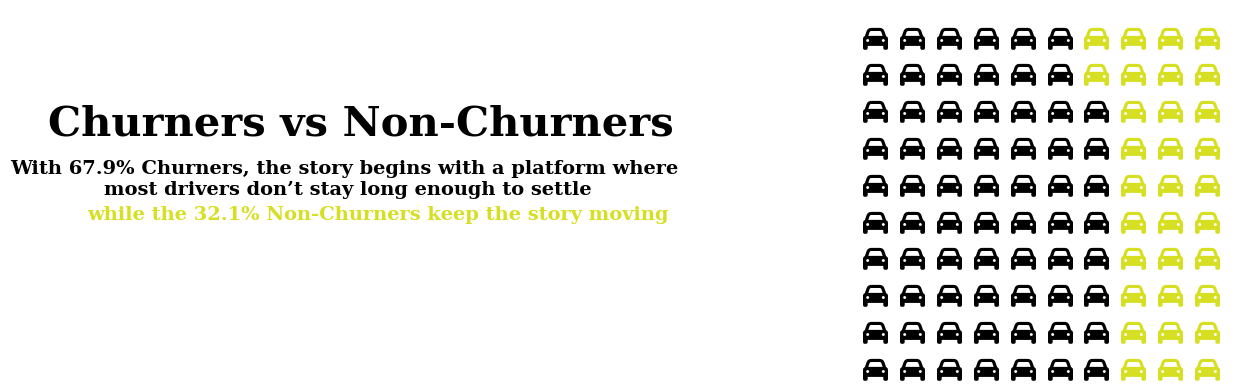

In [11]:
churn_pct = 68
nonchurn_pct = 32
churn_count = round(churn_pct)
nonchurn_count = 100 - churn_count
colors = [black, green]
plot1 = {
    'values': [churn_count, nonchurn_count],'labels': ["Churners", "Non-Churners"],'icons': 'car','colors': colors,'icon_size': 18,'icon_legend': False,
    'interval_ratio_x': 0.001,'interval_ratio_y': 0.001,'plot_anchor': 'C','alpha': 1}
fig = plt.figure(FigureClass=Waffle,plots={111: plot1},rows=10,columns=10,figsize=(20, 4),dpi=100)
fig.set_facecolor("white")
for ax in fig.axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()
fig.text(0,0.65,"Churners vs Non-Churners",fontsize=30,color=black,fontweight='bold',fontfamily=fonts[0])
fig.text(0.15, 0.5,"With 67.9% Churners, the story begins with a platform where \nmost drivers don’t stay long enough to settle",
    fontsize=14,color=black,fontweight='bold',fontfamily=fonts[0],ha='center')
fig.text(0.02, 0.45,"while the 32.1% Non-Churners keep the story moving",fontsize=14,color=green,fontweight='bold',fontfamily=fonts[0],ha='left',va='center')
plt.tight_layout()
fig.subplots_adjust(left=0.05, right=0.95)
plt.show()

In [12]:
churn_only = ola_final[ola_final['target'] == "Churners"]
churn_only['Dateofjoining'] = pd.to_datetime(churn_only['Dateofjoining'])
churn_ts = churn_only.groupby('Dateofjoining').size().reset_index(name='churn_count')
churn_ts = churn_ts.sort_values('Dateofjoining')

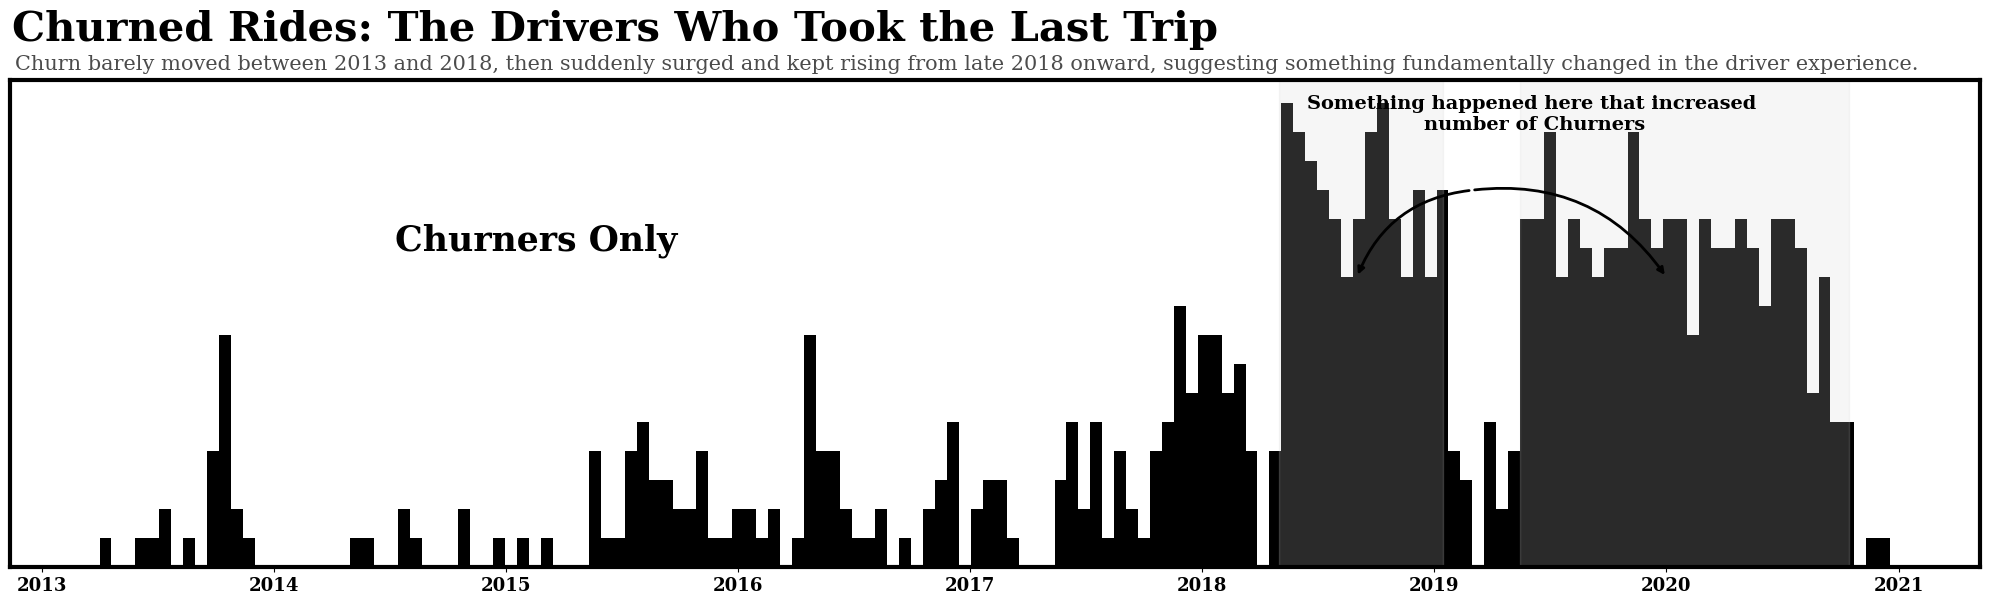

In [13]:
fig, ax = plt.subplots(figsize=(20,6),dpi=100)
fig.suptitle("Churned Rides: The Drivers Who Took the Last Trip",font= fonts[0],color=black,fontsize=30,x=0.31, y=1,fontweight="bold")
# ax.plot(churn_ts['Dateofjoining'], churn_ts['churn_count'], color=green,linewidth=2)
fig.text(0.2,0.6,"Churners Only",color=black,font=fonts[0],fontsize=25,fontweight="bold")
ax.hist(churn_ts['Dateofjoining'], bins=150, color=black, alpha=1)
for spine in ax.spines.values():
    spine.set_color('black');spine.set_linewidth(3)
ax.set_ylabel('');ax.set_xlabel('');ax.set_yticks([])
fig.text(0.01,0.9,"Churn barely moved between 2013 and 2018, then suddenly surged and kept rising from late 2018 onward, suggesting something fundamentally changed in the driver experience.",
         font= fonts[0],color=black,fontsize=15,fontweight="regular",alpha=0.7)
for label in ax.get_xticklabels():
    label.set_fontsize(13);label.set_fontweight('bold');label.set_fontfamily(fonts[0])
ax.axvspan(pd.Timestamp("2018-05-01"), pd.Timestamp("2019-01-15"), color="lightgrey", alpha=0.2)
ax.axvspan(pd.Timestamp("2019-05-15"), pd.Timestamp("2020-10-15"), color="lightgrey", alpha=0.2)
posA = (pd.Timestamp("2019-03-01"), 13)
posB = (pd.Timestamp("2018-09-01"), 10)
arrow_min = FancyArrowPatch(posA=posA, posB=posB,arrowstyle='-|>',connectionstyle="arc3,rad=0.3",color=black,mutation_scale=10,linewidth=2,alpha=1)
ax.add_patch(arrow_min)
posA = (pd.Timestamp("2019-03-01"), 13)
posB = (pd.Timestamp("2020-01-01"), 10)
arrow_min = FancyArrowPatch(posA=posA, posB=posB,arrowstyle='-|>',connectionstyle="arc3,rad=-0.3",color=black,mutation_scale=10,linewidth=2,alpha=1)
ax.add_patch(arrow_min)
fig.text(0.77,0.8,"Something happened here that increased \nnumber of Churners",font= fonts[0],color=black,fontsize=14,fontweight="bold",alpha=1,ha="center")
plt.tight_layout()
plt.show()


Yes. The churn percentage drops from 88.31% in 2018 → 82.74% in 2019 → 46.21% in 2020, which clearly shows that retention has increased significantly over time, especially in 2020. The lower the churn, the higher the retention.

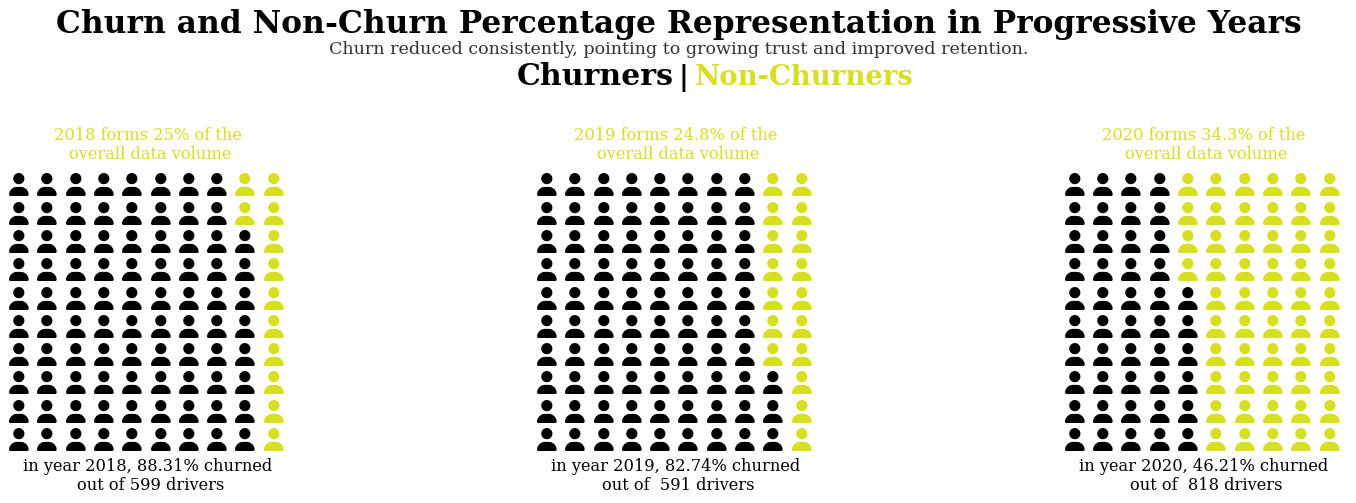

In [14]:
df18 = ola[ola["Year"] == 2018]
df19 = ola[ola["Year"] == 2019]
df20 = ola[ola["Year"] == 2020]

ch18 = round((df18["target"] == "Churners").mean() * 100, 2)
ch19 = round((df19["target"] == "Churners").mean() * 100, 2)
ch20 = round((df20["target"] == "Churners").mean() * 100, 2)

nc18 = round(100 - ch18, 2)
nc19 = round(100 - ch19, 2)
nc20 = round(100 - ch20, 2)

n18 = len(df18)
n19 = len(df19)
n20 = len(df20)

# ---- Plot dictionaries ----
plot_2018 = {'values': [ch18, nc18],'labels': ['Churners', 'Non-Churners'],'icons': ['user', 'user'],'colors': [black, green],'icon_style': ['solid', 'solid'],
    'icon_size': 18,'icon_legend': False,'interval_ratio_x': 0.001,'interval_ratio_y': 0.001,'plot_anchor': 'C','alpha': 0.9}
plot_2019 = {'values': [ch19, nc19],'labels': ['Churners', 'Non-Churners'],'icons': ['user', 'user'],'colors': [black, green],'icon_style': ['solid', 'solid'],
    'icon_size': 18,'icon_legend': False,'interval_ratio_x': 0.001,'interval_ratio_y': 0.001,'plot_anchor': 'C','alpha': 0.9}
plot_2020 = {'values': [ch20, nc20],'labels': ['Churners', 'Non-Churners'],'icons': ['user', 'user'],'colors': [black, green],'icon_style': ['solid', 'solid'],
'icon_size': 18,'icon_legend': False,'interval_ratio_x': 0.001,'interval_ratio_y': 0.001,'plot_anchor': 'C','alpha': 0.9}

# ---- Waffle Figure ----
fig = plt.figure(FigureClass=Waffle,plots={131: plot_2018, 132: plot_2019, 133: plot_2020},rows=10,columns=10,figsize=(18, 5),dpi=90)
fig.suptitle("Churn and Non-Churn Percentage Representation in Progressive Years",font=fonts[0], size=25, color=black, weight='bold',ha="center",x=0.5,y=1.13)
fig.text(0.5, 1.03, "Churn reduced consistently, pointing to growing trust and improved retention.",{'font': fonts[0], 'size': 14, 'color': 'black'}, alpha=0.8,ha="center")
# ---- Text under each waffle ----
fig.axes[0].text(0.5,-0.15,f"in year 2018, {ch18}% churned \nout of {n18} drivers",ha='center', fontdict={'font': fonts[0]}, fontsize=13)
fig.axes[0].text(0.5,1.02,"2018 forms 25% of the \noverall data volume",ha='center', fontdict={'font': fonts[0],"weight":"regular"}, fontsize=13,color=green)
fig.axes[1].text(0.5,-0.15,f"in year 2019, {ch19}% churned \nout of  {n19} drivers",ha='center', fontdict={'font': fonts[0]}, fontsize=13)
fig.axes[1].text(0.5,1.02,"2019 forms 24.8% of the \noverall data volume",ha='center', fontdict={'font': fonts[0],"weight":"regular"}, fontsize=13,color=green)
fig.axes[2].text(0.5,-0.15,f"in year 2020, {ch20}% churned \nout of  {n20} drivers",ha='center', fontdict={'font': fonts[0]}, fontsize=13)
fig.axes[2].text(0.5,1.02,"2020 forms 34.3% of the \noverall data volume",ha='center', fontdict={'font': fonts[0],"weight":"regular"}, fontsize=13,color=green)
# ---- Remove legend from all subplots ----
for ax in fig.axes:
    ax.legend().set_visible(False)
fig.text(0.4,0.96,"Churners",color=black,font=fonts[0],fontsize=24,fontweight="bold")
fig.text(0.5,0.96,"|",color=black,font=fonts[0],fontsize=22,fontweight="bold")
fig.text(0.51,0.96,"Non-Churners",color=green,font=fonts[0],fontsize=22,fontweight="bold")
plt.show()


<h1 style="
  font-family: 'Americana XBdCn BT';
  text-shadow: 2px 2px 4px rgba(0,0,0,0.2);
  font-size: 32px;
  font-style: normal;
  background: linear-gradient(to right, #000000,#000000);
  letter-spacing: 0px;
  color: #d7df23;
  border-radius: 0px;
  text-align: center;
  line-height: 1;
  padding: 20px 10px;
">
  <span>Churn O’Clock: Tracking Drivers Through the (Relative) Passage of TIME</span><br>
</h1>


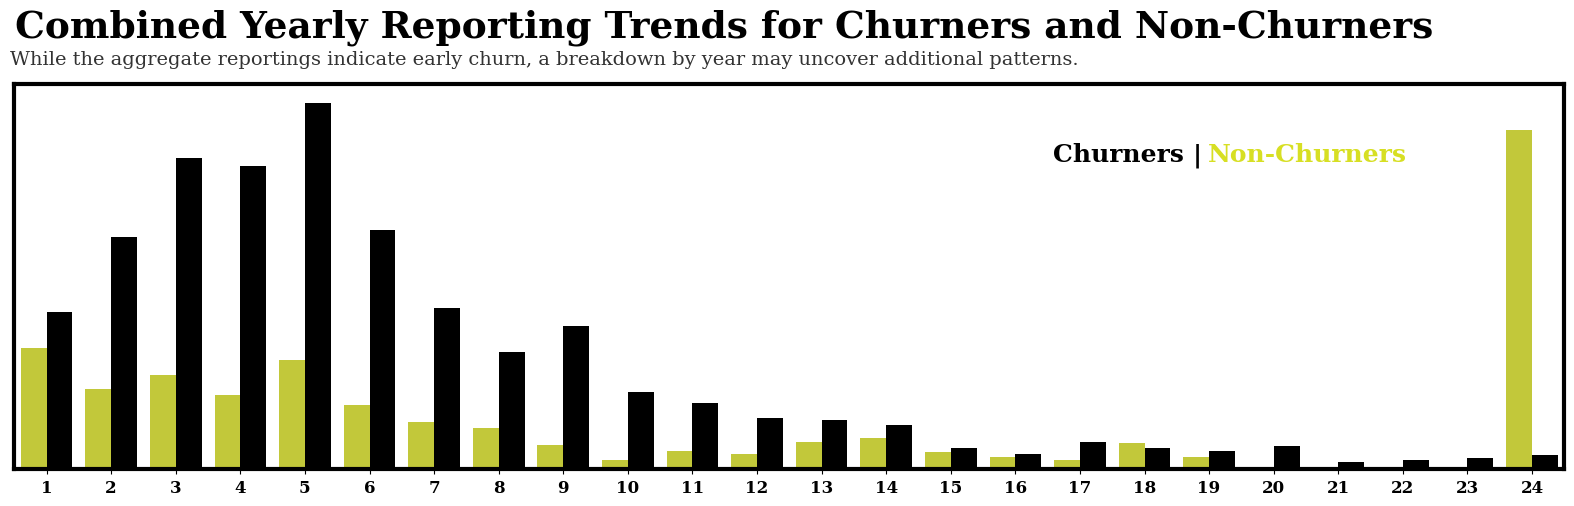

In [25]:
fig, ax = plt.subplots(figsize=(20,5))
fig.suptitle("Combined Yearly Reporting Trends for Churners and Non-Churners",font= fonts[0],color=black,fontsize=27,x=0.48, y=1.03,fontweight="bold",ha="center")
fig.text(0.39, 0.92, "While the aggregate reportings indicate early churn, a breakdown by year may uncover additional patterns.",{'font': fonts[0], 'size': 14, 'color': 'black'}, alpha=0.8,ha="center")
sns.countplot(x=ola["Reportings"],hue=ola["target"],palette={ 'Churners': black, 'Non-Churners': green },ax=ax)
ax.legend_.remove() if ax.legend_ else None
# Customize ticks
ax.set_xticklabels(ax.get_xticklabels(), fontweight='bold', fontsize=12, fontname=fonts[0]);ax.set_yticks([])
ax.set_xlabel('');ax.set_ylabel('')
for spine in ax.spines.values():
    spine.set_color('black');spine.set_linewidth(3)
# ax.text(15,100,"Reportings",font=fonts[0],fontsize=20,color=green)
add_stroke_labels(ax=ax, fontsize=18, x_vals=[0.67, 0.76, 0.77], y=0.8,
                  labels=["Churners", "|", "Non-Churners"], colors=[black, "black", green])
plt.show()

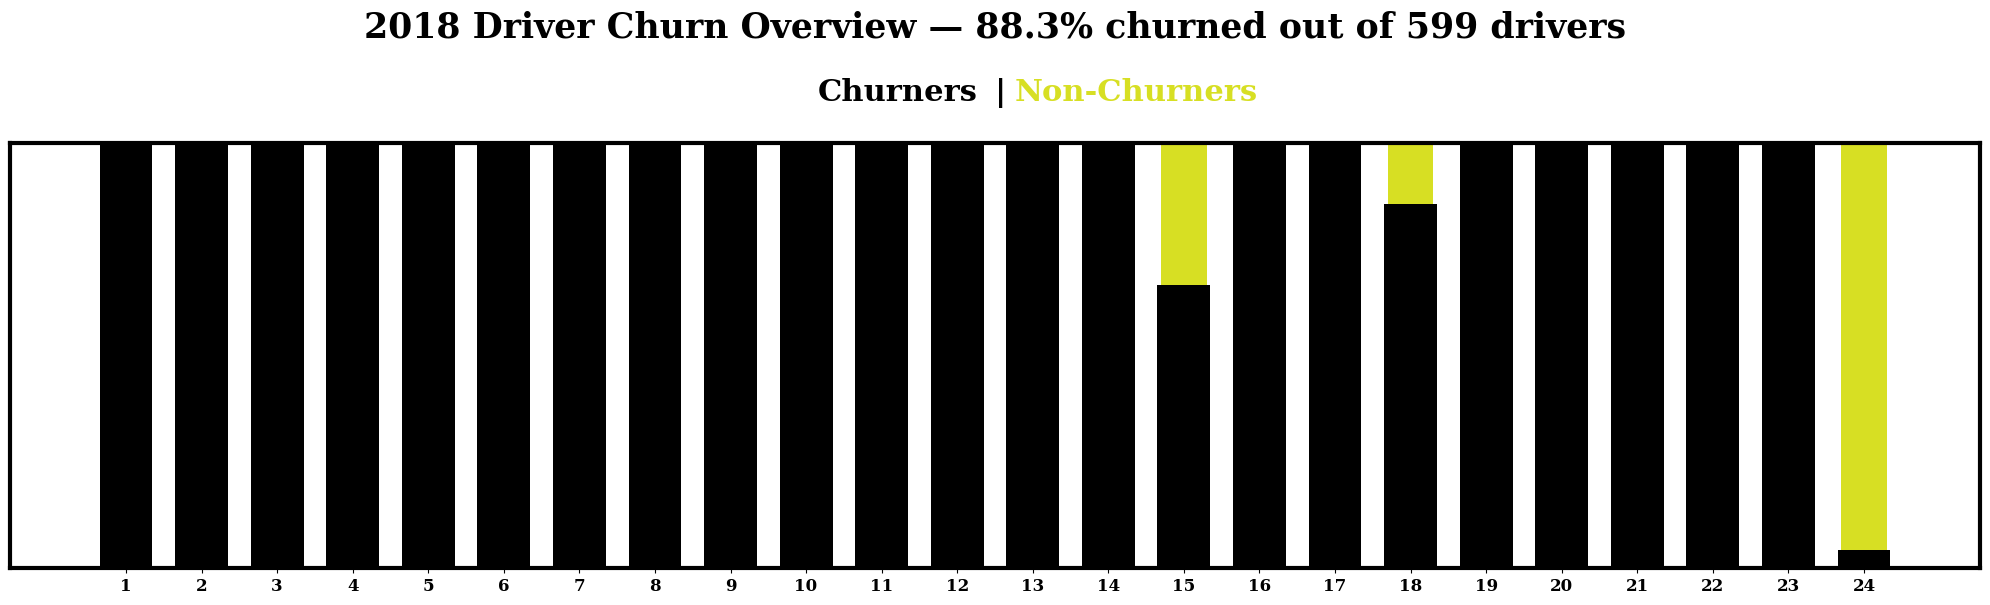

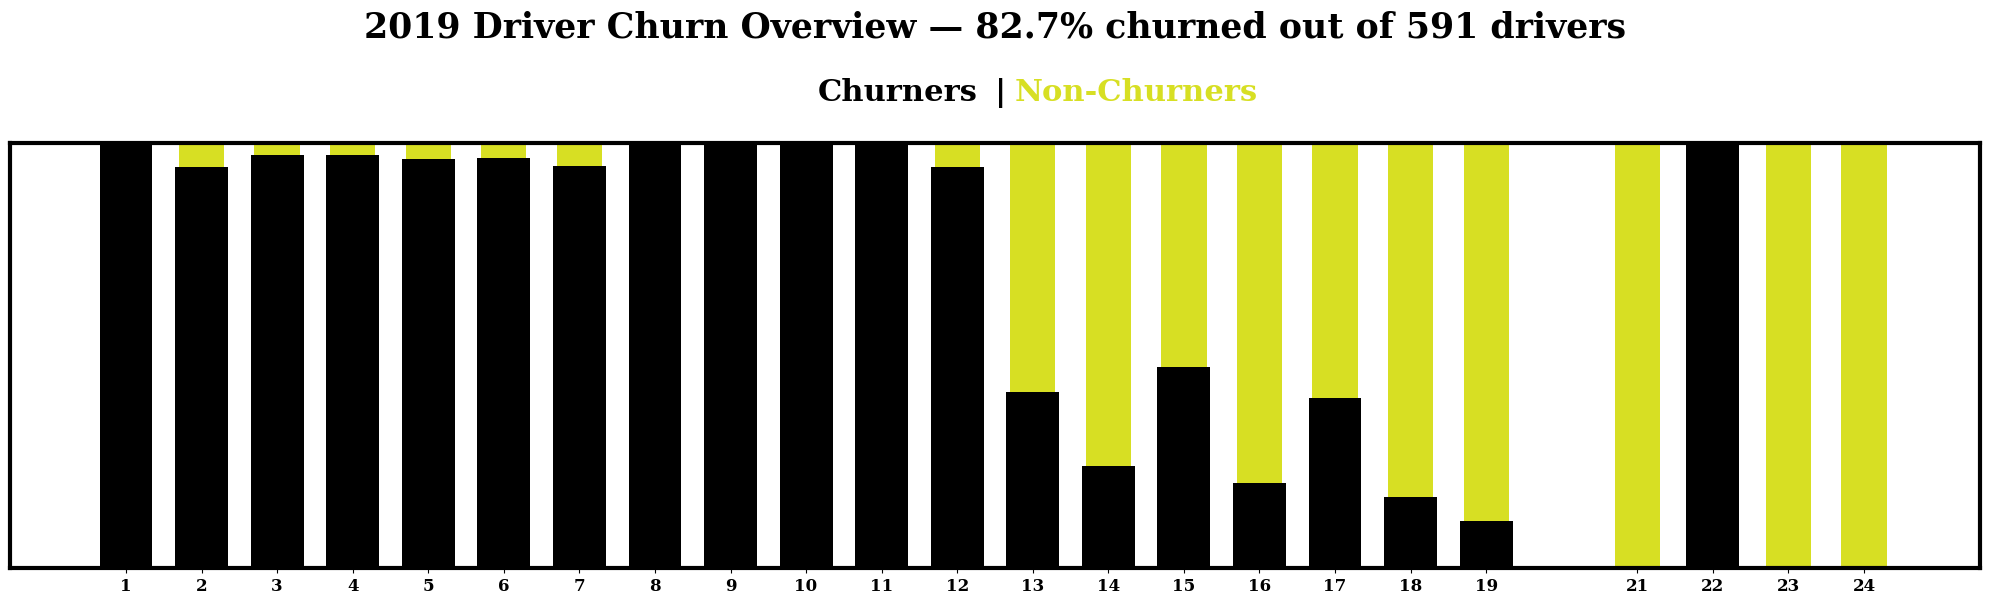

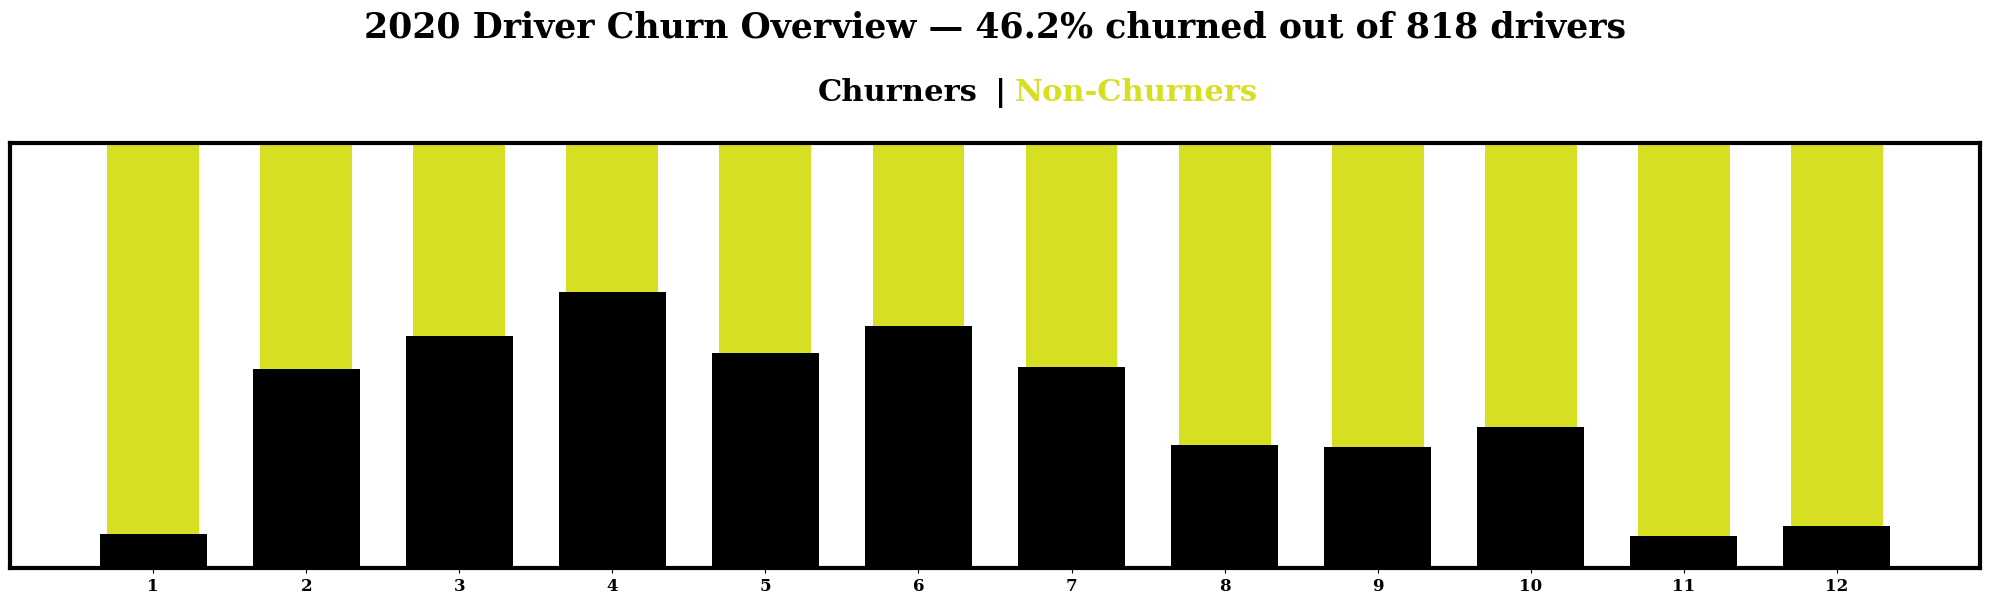

In [26]:
def plot_churn_by_year(ola, year):
    df_year = ola[ola["Year"] == year]
    counts = df_year.groupby(["Reportings", "target"]).size().unstack(fill_value=0)
    percents = counts.div(counts.sum(axis=1), axis=0) * 100
    total_drivers = len(df_year)
    churn_percent = len(df_year[df_year["target"] == "Churners"]) / total_drivers * 100
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.bar(percents.index, percents["Churners"], color=black, width=0.7, label="Churners")
    ax.bar(percents.index, percents["Non-Churners"], bottom=percents["Churners"], color=green, width=0.6, label="Non-Churners")
    ax.set_xlabel("", fontsize=14);ax.set_ylabel("", fontsize=14);ax.set_yticks([]);ax.set_ylim(0, 100)
    ax.set_xticks(percents.index);ax.set_xticklabels(percents.index, fontdict={'font': fonts[0], 'weight': 'bold', 'size': 12})
    for spine in ax.spines.values():
        spine.set_color(black);spine.set_linewidth(3)
    add_stroke_labels(ax=ax, fontsize=22, x_vals=[0.41, 0.5, 0.51], y=1.1,labels=["Churners", "|", "Non-Churners"], colors=[black, "black", green])
    subtitle_text = f"{year} Driver Churn Overview — {round(churn_percent, 1)}% churned out of {total_drivers} drivers"
    fig.suptitle(subtitle_text, fontsize=25,font=fonts[0],fontweight="bold", fontname=fonts[0], color=black, y=1)   
    plt.tight_layout()
    plt.show()
plot_churn_by_year(ola, 2018)
plot_churn_by_year(ola, 2019)
plot_churn_by_year(ola, 2020)


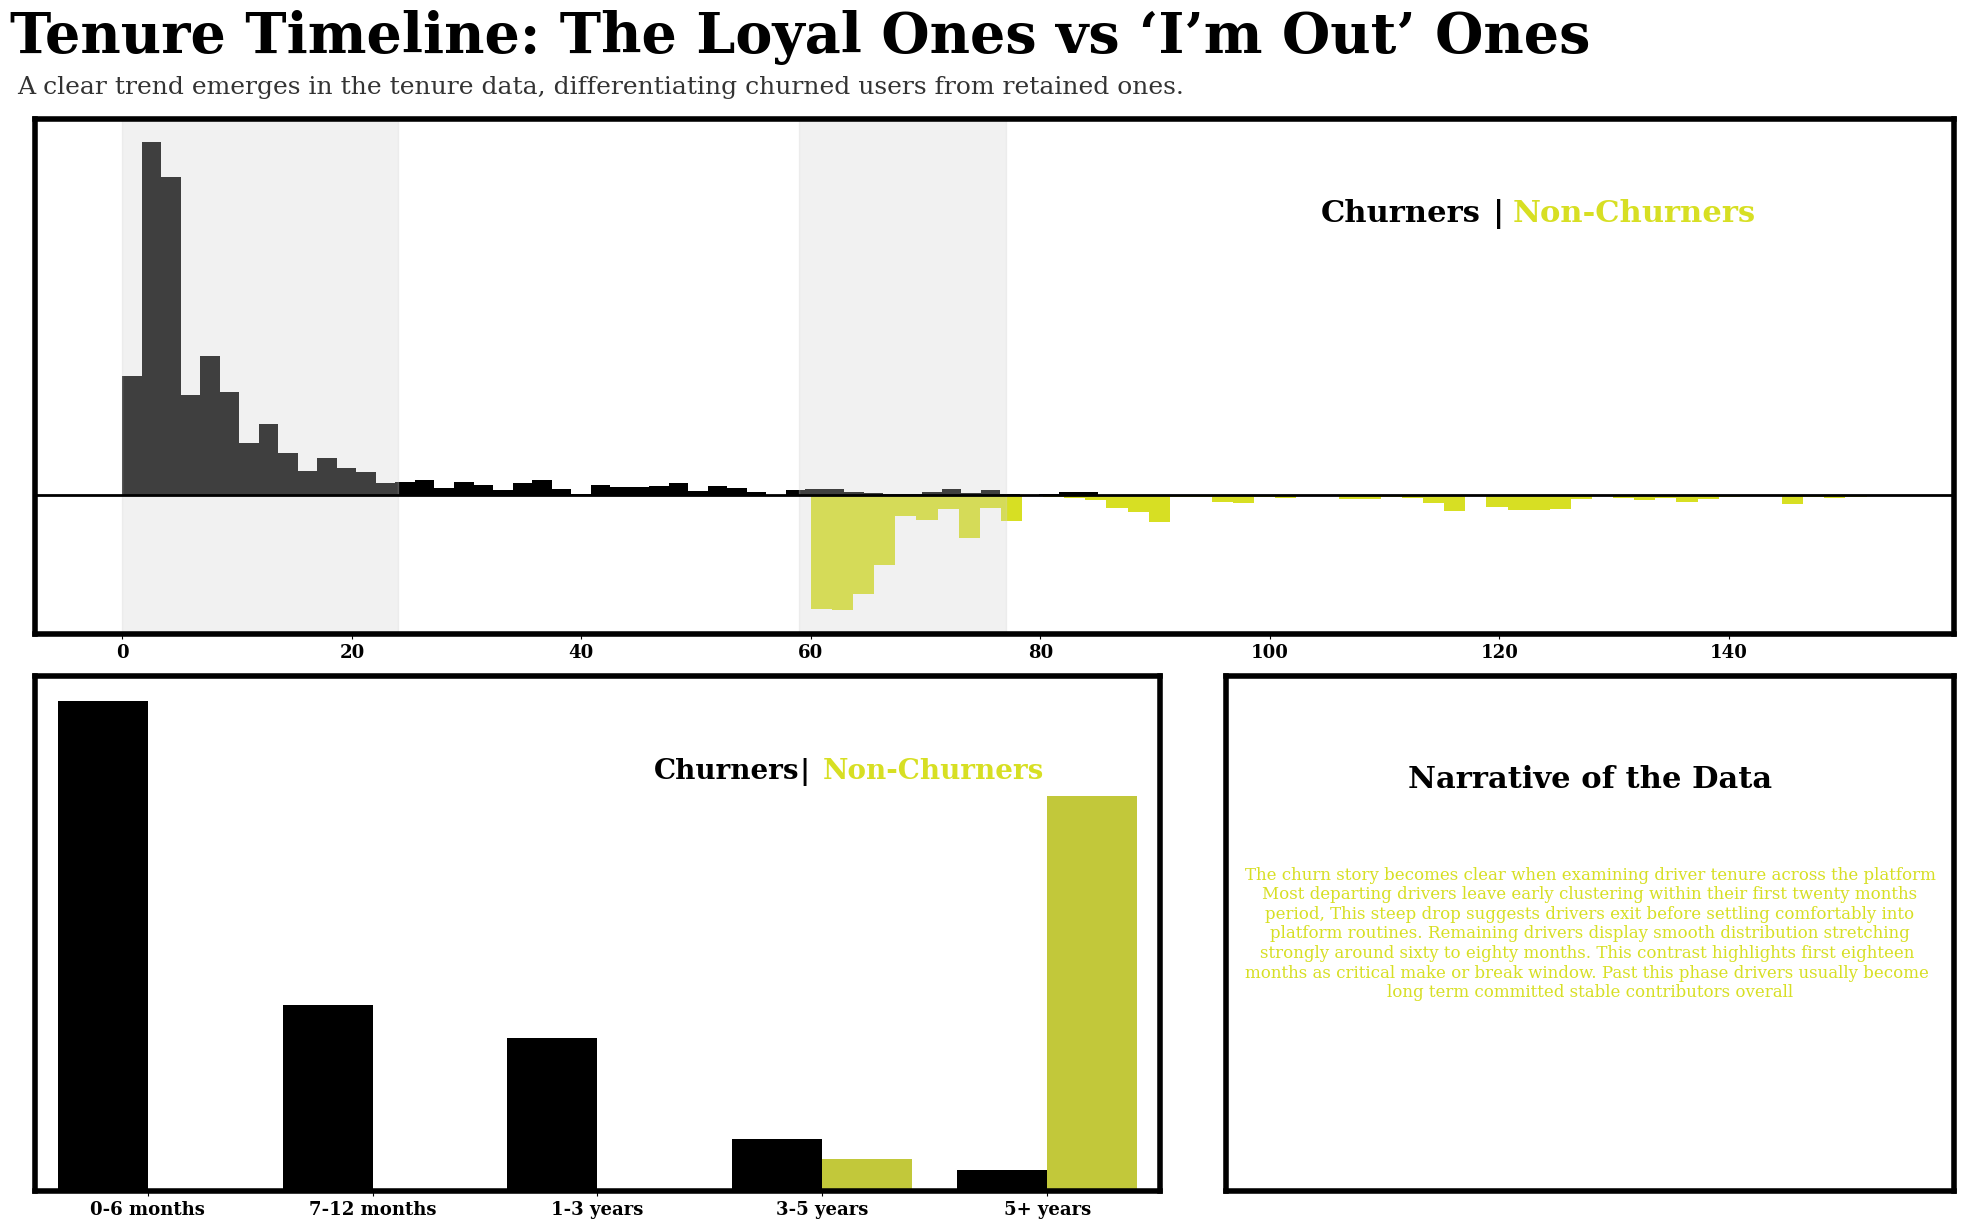

In [27]:
fig = plt.figure(figsize=(20,12), dpi=100)
fig.suptitle("Tenure Timeline: The Loyal Ones vs ‘I’m Out’ Ones",font= fonts[0],color=black,fontsize=40,x=0.39, y=1.02,fontweight="bold",ha="center")
ax1 = plt.subplot2grid((2,5), (0,0), colspan=5)
bins = 50
churners = ola[ola["target"] == 'Churners']["Tenure_Months"]
ax1.hist(churners, bins=bins, color=black, alpha=1)
non_churners = ola[ola["target"] == 'Non-Churners']["Tenure_Months"]
ax1.hist(non_churners, bins=bins, color=green, alpha=1,weights=-np.ones_like(non_churners))
ax1.set_xticks(ax1.get_xticks());ax1.set_yticks([])
for spine in ax1.spines.values():
    spine.set_color('black'); spine.set_linewidth(4)
ax1.set_xticklabels(ax1.get_xticklabels(),fontweight='bold', fontsize=13, fontname=fonts[0])
ax1.axhline(0, color='black', linewidth=2);ax1.axvspan(0, 24, color='lightgrey', alpha=0.3);ax1.axvspan(59, 77, color='lightgrey', alpha=0.3)
# ROW 2 → COUNT PLOT (COLSPAN 4)
ax2 = plt.subplot2grid((2,5), (1,0), colspan=3)
sns.countplot(x=ola["tenure_bin"],hue=ola["target"],palette={'Churners': black, 'Non-Churners': green},ax=ax2)
if ax2.legend_:
    ax2.legend_.remove()
ax2.set_xticklabels(ax2.get_xticklabels(),fontweight='bold', fontsize=13, fontname=fonts[0])
ax2.set_yticks([]);ax2.set_xlabel(''); ax2.set_ylabel('')
for spine in ax2.spines.values():
    spine.set_color('black'); spine.set_linewidth(4)
# ax2.text(0.5, max(ax2.get_ylim())*0.8, "tenure_bins",font=fonts[0], fontsize=20, color=green)
# ROW 2 → EMPTY BOX (LAST COLUMN)
ax3 = plt.subplot2grid((2,5), (1,3), colspan=2)
ax3.set_xticks([]); ax3.set_yticks([])
for spine in ax3.spines.values():
    spine.set_color('black'); spine.set_linewidth(4)
ax3.text(0.5, 0.8, "Narrative of the Data",ha="center", va="center",fontsize=22, fontweight="bold",color=black, font=fonts[0])
ax3.text(
    0.5, 0.5,
    "The churn story becomes clear when examining driver tenure across the platform"
    "\nMost departing drivers leave early clustering within their first twenty months"
    "\nperiod, This steep drop suggests drivers exit before settling comfortably into"
    "\nplatform routines. Remaining drivers display smooth distribution stretching"
    "\nstrongly around sixty to eighty months. This contrast highlights first eighteen "
    "\nmonths as critical make or break window. Past this phase drivers usually become "
    "\nlong term committed stable contributors overall",
    fontsize=12, color=green, font=fonts[0], ha="center",va="center", fontweight="regular")
add_stroke_labels(ax=ax1, fontsize=22, x_vals=[0.67, 0.76, 0.77], y=0.8,labels=["Churners", "|", "Non-Churners"], colors=[black, "black", green])
add_stroke_labels(ax=ax2, fontsize=20, x_vals=[0.55, 0.68, 0.7], y=0.8,labels=["Churners", "|", "Non-Churners"], colors=[black, "black", green])
fig.text(0.29, 0.95, "A clear trend emerges in the tenure data, differentiating churned users from retained ones.",
         {'font': fonts[0], 'size': 18, 'color': 'black'}, alpha=0.8,ha="center")
plt.tight_layout()
plt.show()


<h1 style="
  font-family: 'Americana XBdCn BT';
  text-shadow: 2px 2px 4px rgba(0,0,0,0.2);
  font-size: 32px;
  font-style: normal;
  background: linear-gradient(to right, #000000,#000000);
  letter-spacing: 0px;
  color: #d7df23;
  border-radius: 0px;
  text-align: center;
  line-height: 1;
  padding: 20px 10px;
">
  <span>Why & How Drivers Stick or Exit: Exploring Demographics, Performance Score and Increments</span><br>
</h1>


In [15]:
def pieMarkerPlot(df, cat_col, target_col='target', years_of_interest=[2018,2019,2020], flat_columns=None, ax=None):
    df_cat = df[df['Year'].isin(years_of_interest)]
    # -------------------
    # 2. Pivot table
    # -------------------
    cat_year_counts = df_cat.pivot_table(
        index=cat_col,
        columns=['Year', target_col],
        values='Driver_ID',
        aggfunc='count',
        fill_value=0
    ).reset_index()
    # -------------------
    # 3. Flatten multi-level columns (manual)
    # -------------------
    if flat_columns is not None:
        cat_year_counts.columns = flat_columns
    else:
        raise ValueError("Please provide 'flat_columns' for pivoted table")

    # -------------------
    # 4. Prepare mapping
    # -------------------
    cat_order = sorted(cat_year_counts[cat_col].unique())
    year_order = [str(y) for y in years_of_interest]
    cat_to_num = {c:i for i, c in enumerate(cat_order)}
    year_to_num = {y:i for i, y in enumerate(year_order)}

    # -------------------
    # 5. Prepare plotting values
    # -------------------
    xs, ys, ratios, sizes = [], [], [], []

    for _, row in cat_year_counts.iterrows():
        for year in year_order:
            xs.append(cat_to_num[row[cat_col]])
            ys.append(year_to_num[year])
            churn = row[f"{year}_Churners"]
            non_churn = row[f"{year}_NonChurners"]
            total = churn + non_churn
            if total > 0:
                ratios.append([churn/total, non_churn/total])
            else:
                ratios.append([0,0])
            sizes.append(np.sqrt(total)*0.0025)
    # -------------------
    # 6. Plotting
    # -------------------
    color_churners = '#000000'
    color_nonchurners = '#d7df23'
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,6))
    for (x, y, ratio, size) in zip(xs, ys, ratios, sizes):
        start = 0
        for frac, color in zip(ratio, [color_churners, color_nonchurners]):
            theta1, theta2 = start*360, (start+frac)*360
            wedge = Wedge(center=(x, y), r=np.sqrt(size), theta1=theta1, theta2=theta2,facecolor=color, edgecolor=None)
            ax.add_patch(wedge)
            start += frac
    ax.set_xlim(-0.5, len(cat_order)-0.5);ax.set_ylim(-0.5, len(year_order)-0.5);ax.set_xticks(range(len(cat_order)))
    ax.set_xticklabels(cat_order, rotation=0, fontfamily=fonts[0], fontsize=12, fontweight="bold", color='black')
    ax.set_yticks(range(len(year_order)));ax.set_yticklabels(year_order, fontfamily=fonts[0], fontsize=12, fontweight="bold", color='black')
    ax.invert_yaxis()
    ax.grid(True, which='major', axis='both', color='gray', linestyle='--', linewidth=0.5, alpha=0.1)
    for spine in ax.spines.values():
        spine.set_color('black');spine.set_linewidth(3)
    ax.set_title(f"Staying or Straying: \n{cat_col} Insights",fontsize=16, fontweight="bold", fontname=fonts[0], color=green)
    if ax is None:
        plt.show()


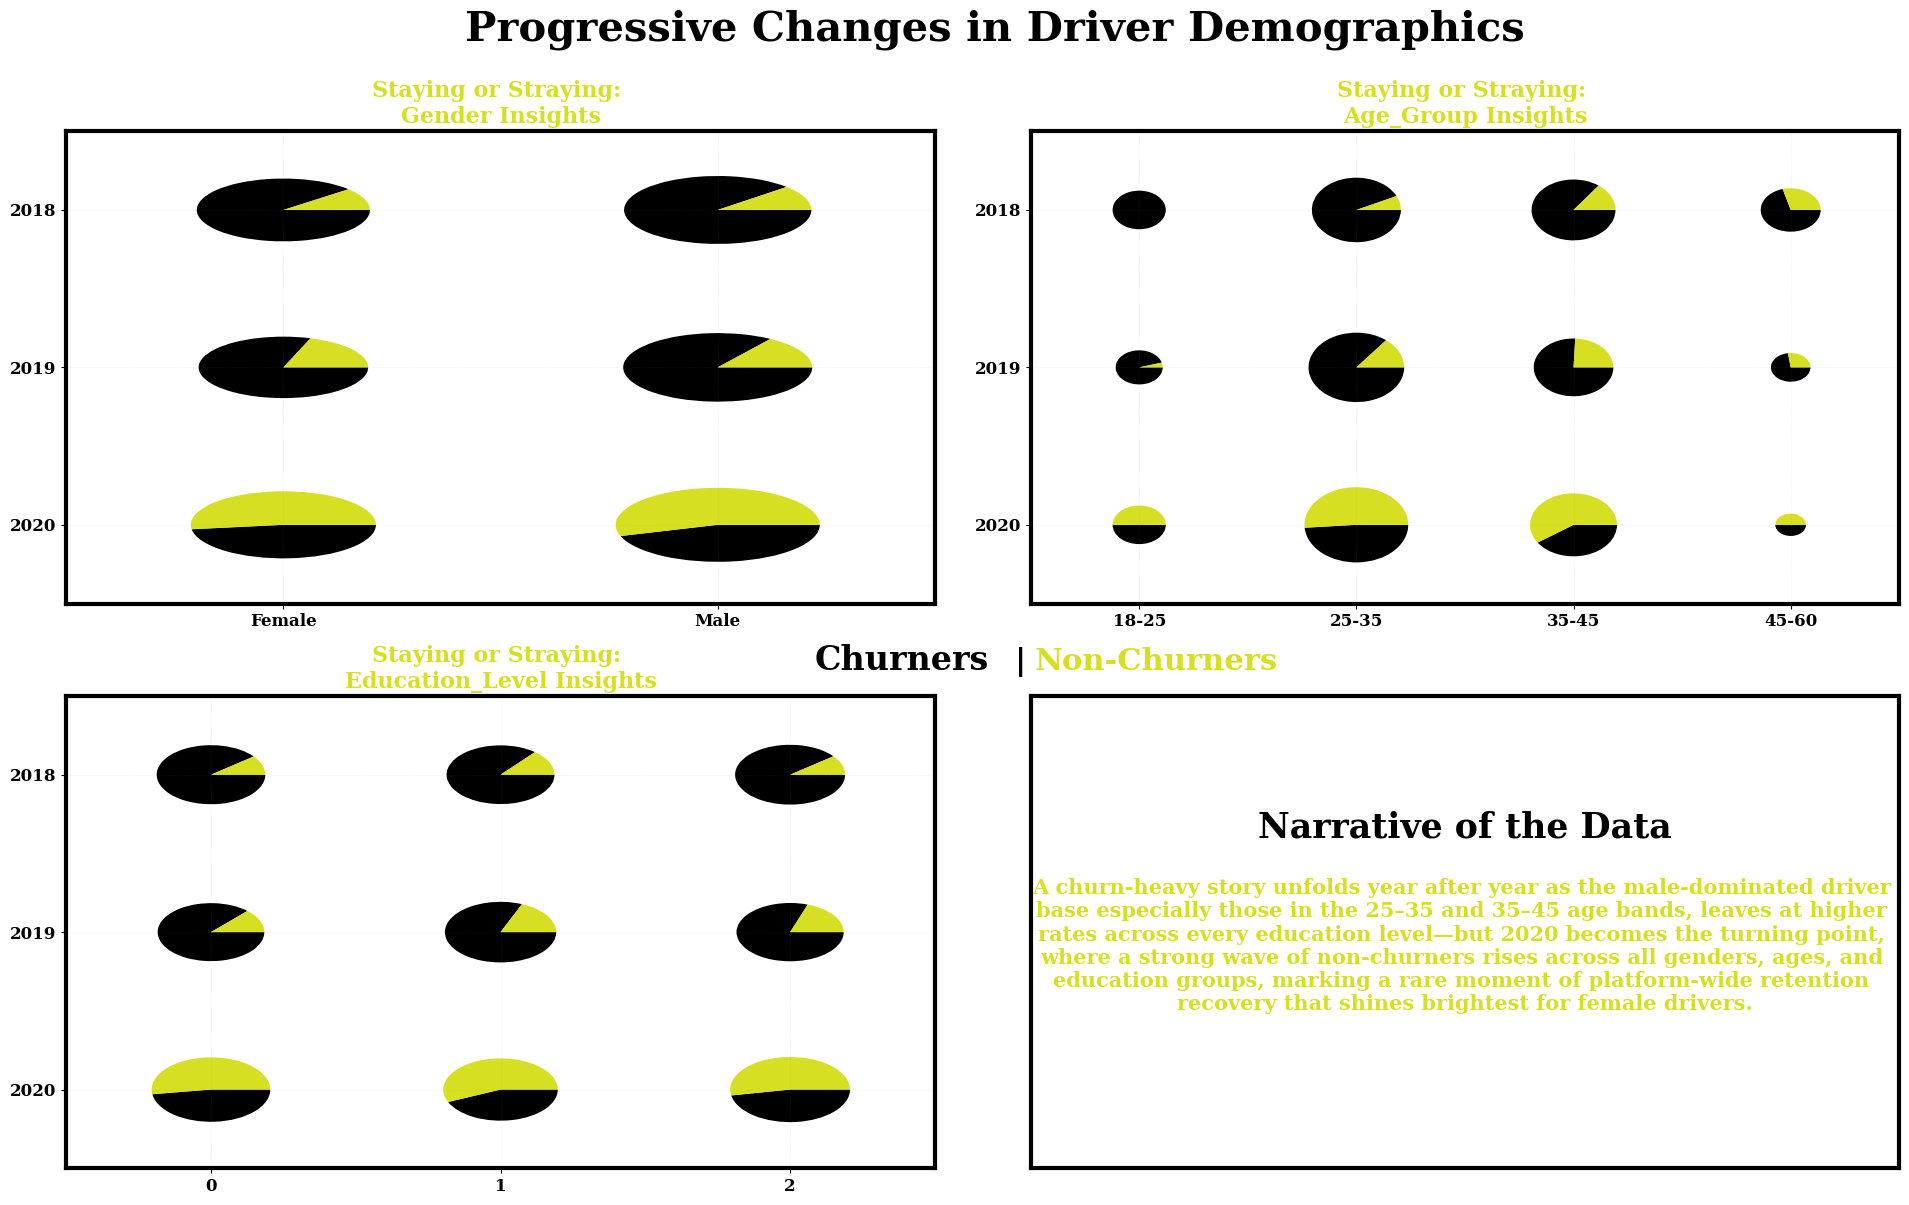

In [16]:
fig = plt.figure(figsize=(20,12),dpi=100)
fig.suptitle("Progressive Changes in Driver Demographics",font= fonts[0],color=black,fontsize=30,x=0.5, y=1,fontweight="bold",ha="center")
fig.text(0.41,0.45,"Churners",color=black,font=fonts[0],fontsize=24,fontweight="bold")
fig.text(0.51,0.45,"|",color=black,font=fonts[0],fontsize=22,fontweight="bold")
fig.text(0.52,0.45,"Non-Churners",color=green,font=fonts[0],fontsize=22,fontweight="bold")
# ------------------ Gender ------------------
flat_cols_gender = ['Gender','2018_Churners', '2018_NonChurners','2019_Churners', '2019_NonChurners','2020_Churners', '2020_NonChurners']
ax1 = plt.subplot2grid((2,2), (0,0))
pieMarkerPlot(ola, 'Gender', years_of_interest=[2018,2019,2020], flat_columns=flat_cols_gender, ax=ax1)
# ------------------ Age Group ------------------
flat_cols_age = ['Age_Group','2018_Churners', '2018_NonChurners','2019_Churners', '2019_NonChurners','2020_Churners', '2020_NonChurners']
ax2 = plt.subplot2grid((2,2), (0,1))
pieMarkerPlot(ola, 'Age_Group', years_of_interest=[2018,2019,2020], flat_columns=flat_cols_age, ax=ax2)
# ------------------ Education Level ------------------
flat_cols_edu = ['Education_Level','2018_Churners', '2018_NonChurners','2019_Churners', '2019_NonChurners','2020_Churners', '2020_NonChurners']
ax3 = plt.subplot2grid((2,2), (1,0))
pieMarkerPlot(ola, 'Education_Level', years_of_interest=[2018,2019,2020], flat_columns=flat_cols_edu, ax=ax3)
# ------------------ Leave last subplot empty ------------------
ax4 = plt.subplot2grid((2,2), (1,1))
ax4.set_xticks([]); ax4.set_yticks([]); ax4.grid(False)
# Title (centered)
ax4.text(0.5, 0.85, "Narrative of the Data",
         ha="center", va="center",
         fontsize=22, fontweight="bold",
         color=black, font=fonts[0])

# Context paragraph
ax4 = plt.subplot2grid((2,2), (1,1))
ax4.set_xticks([]); ax4.set_yticks([]); ax4.grid(False)
ax4.text(0.5,0.7,"Narrative of the Data",fontsize=25, fontweight="bold",ha="center",color=black,font=fonts[0])
ax4.text(
    0.5, 0.47,
    "A churn-heavy story unfolds year after year as the male-dominated driver \n"
    "base especially those in the 25–35 and 35–45 age bands, leaves at higher \n"
    "rates across every education level—but 2020 becomes the turning point, \n"
    "where a strong wave of non-churners rises across all genders, ages, and \n"
    "education groups, marking a rare moment of platform-wide retention \n"
    "recovery that shines brightest for female drivers.",
    ha="center", va="center",
    fontsize=15, color=green, font=fonts[0], wrap=True, fontweight="bold"
)




for spine in ax4.spines.values():
    spine.set_color('black');spine.set_linewidth(3)
plt.tight_layout()
plt.show()


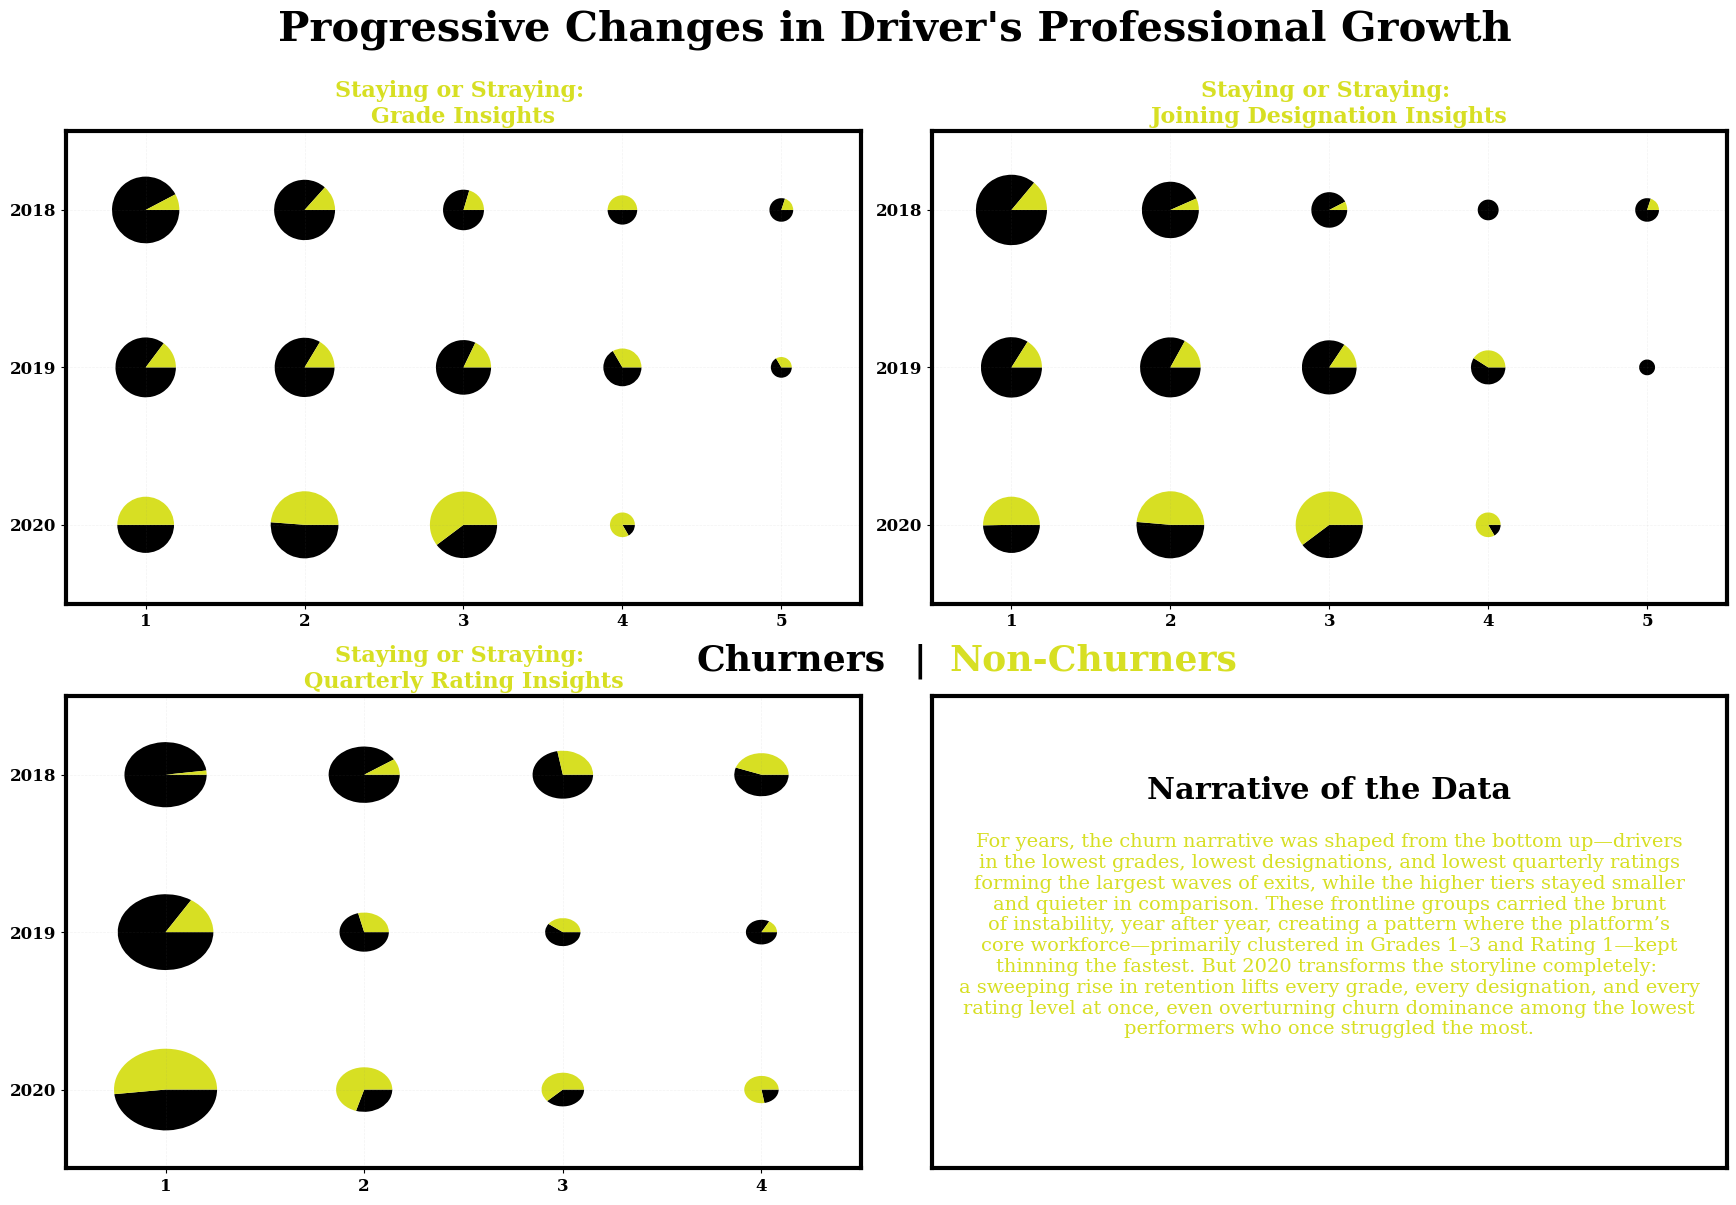

In [17]:
fig = plt.figure(figsize=(18,12),dpi=100)
fig.suptitle("Progressive Changes in Driver's Professional Growth",font= fonts[0],color=black,fontsize=30,x=0.5, y=1,fontweight="bold",ha="center")
fig.text(0.39,0.45,"Churners",color=black,font=fonts[0],fontsize=26,fontweight="bold")
fig.text(0.51,0.45,"|",color=black,font=fonts[0],fontsize=25,fontweight="bold")
fig.text(0.53,0.45,"Non-Churners",color=green,font=fonts[0],fontsize=26,fontweight="bold")
# ------------------ Gender ------------------
flat_cols_gender = ['Grade','2018_Churners', '2018_NonChurners','2019_Churners', '2019_NonChurners','2020_Churners', '2020_NonChurners']
ax1 = plt.subplot2grid((2,2), (0,0))
pieMarkerPlot(ola, 'Grade', years_of_interest=[2018,2019,2020], flat_columns=flat_cols_gender, ax=ax1)
# ------------------ Age Group ------------------
flat_cols_age = ['Joining Designation','2018_Churners', '2018_NonChurners','2019_Churners', '2019_NonChurners','2020_Churners', '2020_NonChurners']
ax2 = plt.subplot2grid((2,2), (0,1))
pieMarkerPlot(ola, 'Joining Designation', years_of_interest=[2018,2019,2020], flat_columns=flat_cols_age, ax=ax2)
# ------------------ Education Level ------------------
flat_cols_edu = ['Quarterly Rating','2018_Churners', '2018_NonChurners','2019_Churners', '2019_NonChurners','2020_Churners', '2020_NonChurners']
ax3 = plt.subplot2grid((2,2), (1,0))
pieMarkerPlot(ola, 'Quarterly Rating', years_of_interest=[2018,2019,2020], flat_columns=flat_cols_edu, ax=ax3)
# ------------------ Leave last subplot empty ------------------
ax4 = plt.subplot2grid((2,2), (1,1))
ax4.set_xticks([]);ax4.set_yticks([]);ax4.grid(False)
ax4.text(0.5, 0.8, "Narrative of the Data",ha="center", va="center",fontsize=22, fontweight="bold",color=black, font=fonts[0])
ax4.text(
    0.5, 0.47,
    "For years, the churn narrative was shaped from the bottom up—drivers"
    "\nin the lowest grades, lowest designations, and lowest quarterly ratings"
    "\nforming the largest waves of exits, while the higher tiers stayed smaller"
    "\nand quieter in comparison. These frontline groups carried the brunt"
    "\nof instability, year after year, creating a pattern where the platform’s"
    "\ncore workforce—primarily clustered in Grades 1–3 and Rating 1—kept"
    "\nthinning the fastest. But 2020 transforms the storyline completely: "
    "\na sweeping rise in retention lifts every grade, every designation, and every"
    "\nrating level at once, even overturning churn dominance among the lowest"
    "\nperformers who once struggled the most.\n",
    ha="center", va="center",
    fontsize=14, color=green, font=fonts[0],
    wrap=True, fontweight="regular"
)
for spine in ax4.spines.values():
    spine.set_color('black');spine.set_linewidth(3)
plt.tight_layout()
plt.show()

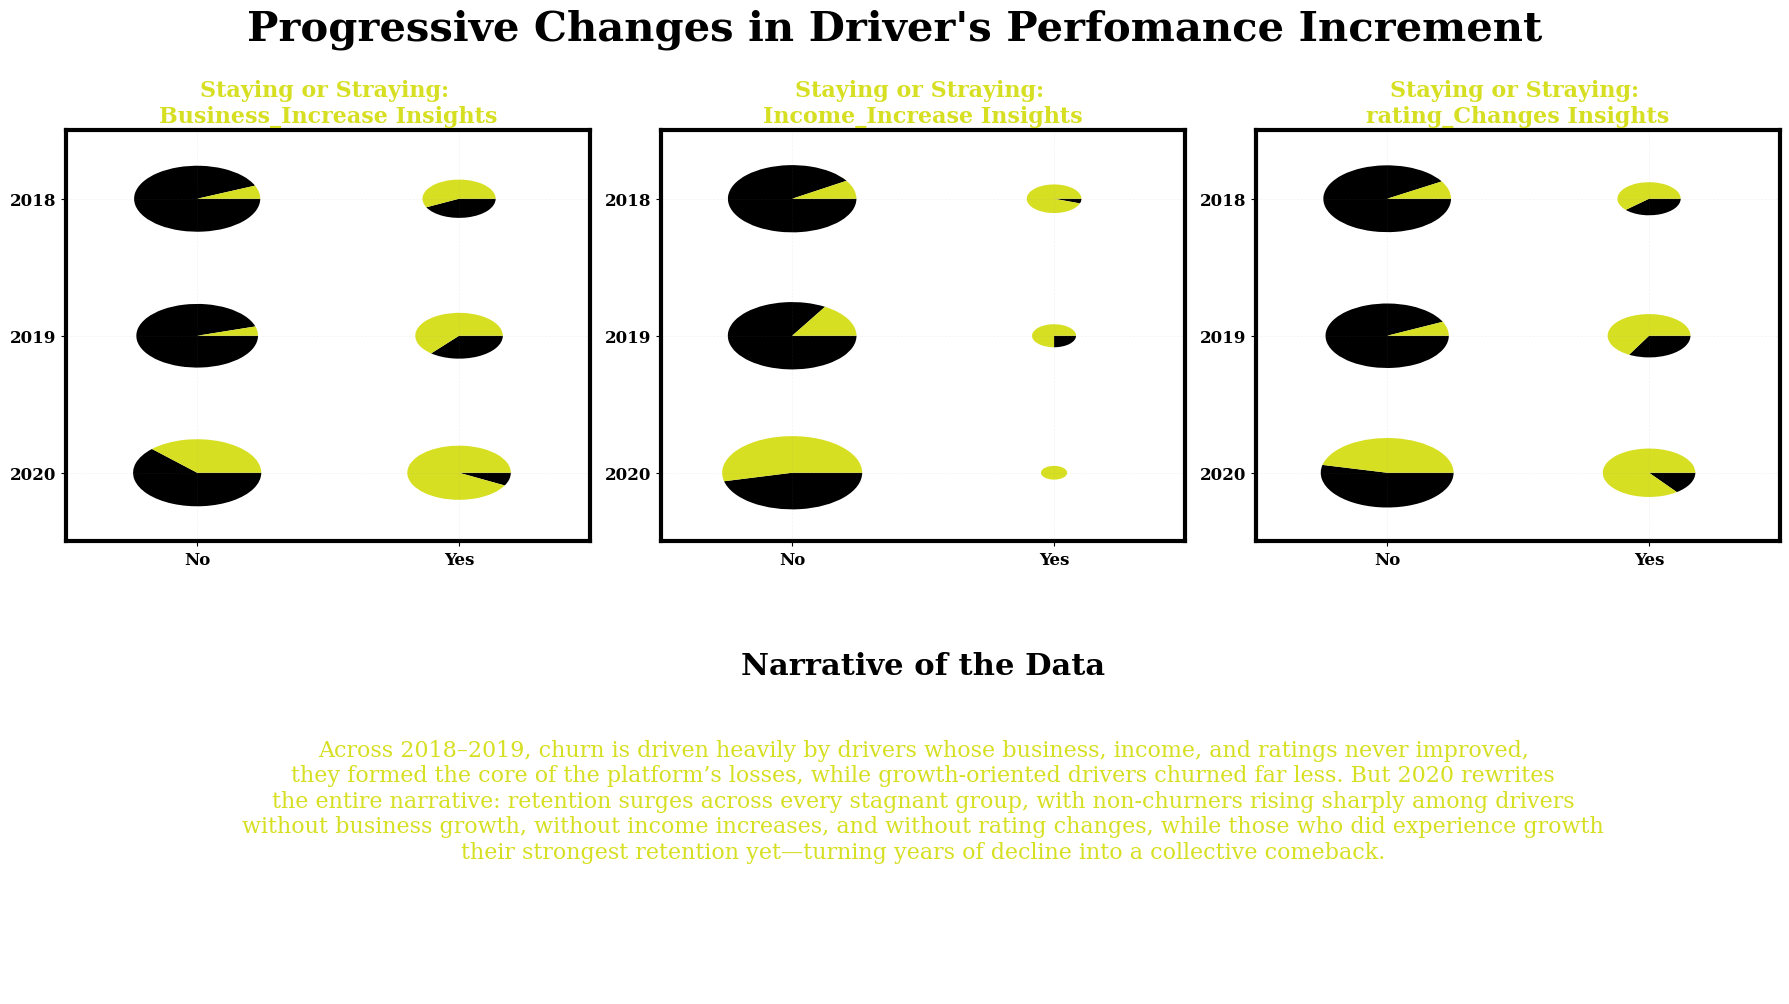

In [18]:
fig = plt.figure(figsize=(18,10),dpi=100)
fig.suptitle("Progressive Changes in Driver's Perfomance Increment",font= fonts[0],color=black,fontsize=30,x=0.5, y=1,fontweight="bold",ha="center")
# fig.text(0.39,-0.05,"Churners",color=black,font=fonts[0],fontsize=25,fontweight="bold")
# fig.text(0.5,-0.05,"|",color=black,font=fonts[0],fontsize=25,fontweight="bold")
# fig.text(0.52,-0.05,"Non-Churners",color=green,font=fonts[0],fontsize=25,fontweight="bold")
# ------------------ Gender ------------------
flat_cols_gender = ['Business_Increase','2018_Churners', '2018_NonChurners','2019_Churners', '2019_NonChurners','2020_Churners', '2020_NonChurners']
ax1 = plt.subplot2grid((2,3), (0,0))
pieMarkerPlot(ola, 'Business_Increase', years_of_interest=[2018,2019,2020], flat_columns=flat_cols_gender, ax=ax1)
# ------------------ Age Group ------------------
flat_cols_age = ['Income_Increase','2018_Churners', '2018_NonChurners','2019_Churners', '2019_NonChurners','2020_Churners', '2020_NonChurners']
ax2 = plt.subplot2grid((2,3), (0,1))
pieMarkerPlot(ola, 'Income_Increase', years_of_interest=[2018,2019,2020], flat_columns=flat_cols_age, ax=ax2)
# ------------------ Education Level ------------------
flat_cols_edu = ['rating_Changes','2018_Churners', '2018_NonChurners','2019_Churners', '2019_NonChurners','2020_Churners', '2020_NonChurners']
ax3 = plt.subplot2grid((2,3), (0,2))
pieMarkerPlot(ola, 'rating_Changes', years_of_interest=[2018,2019,2020], flat_columns=flat_cols_edu, ax=ax3)
ax4 = plt.subplot2grid((2,3), (1,0),colspan=3)
ax4.set_xticks([]);ax4.set_yticks([]);ax4.grid(False)
ax4.text(0.5, 0.8, "Narrative of the Data",ha="center", va="center",fontsize=22, fontweight="bold",color=black, font=fonts[0])
ax4.text(
    0.5, 0.47,
    "Across 2018–2019, churn is driven heavily by drivers whose business, income, and ratings never improved,"
    "\nthey formed the core of the platform’s losses, while growth-oriented drivers churned far less. But 2020 rewrites"
    "\nthe entire narrative: retention surges across every stagnant group, with non-churners rising sharply among drivers"
    "\nwithout business growth, without income increases, and without rating changes, while those who did experience growth"
    "\ntheir strongest retention yet—turning years of decline into a collective comeback.",
    ha="center", va="center",
    fontsize=16, color=green, font=fonts[0],
    wrap=True, fontweight="regular"
)
for spine in ax4.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()